<a href="https://colab.research.google.com/github/ksdhariwal/Data-Analysis-ML/blob/main/Comparing%20Classifiers/notebook/Bank%20Marketing%20Dataset%E2%80%94Comparing_Classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Term Deposit Subscription Using Classification Models**

### Business Problem:

The bank conducts telemarketing campaigns to promote long‑term deposits.
These campaigns are expensive and time‑consuming, and the success rate is low.

### Business Goal:

Identify which clients are most likely to subscribe to a term deposit so the bank can:
*   Reduce unnecessary calls
*   Improve conversion rates
*   Allocate marketing resources efficiently
*   Increase ROI

### Project Objective:
In this practical application, we aim to compare the performance of several classifiers —
K-Nearest Neighbors (KNN), Logistic Regression, Decision Trees, and Support Vector Machines (SVM) —
using the [UCI Bank Marketing dataset](https://archive.ics.uci.edu/ml/datasets/bank+marketing).

The dataset is related to direct marketing campaigns of a Portuguese banking institution.
The classification goal is to predict whether a client will subscribe to a term deposit (`y`).

We will use the **`bank-additional-full.csv`** file, which contains all examples (41,188) and 20 input features.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

---
## Problem 1: Understanding the Data — How Many Marketing Campaigns?

Read through the data description at the [UCI link](https://archive.ics.uci.edu/ml/datasets/bank+marketing)
to gain an understanding of the data. How many marketing campaigns does this data represent?

Answer:

According to the UCI dataset description, this data is related to 17 campaigns carried out between May 2008 and November 2010, corresponding to a total of 79,354 contacts. The bank-additional-full.csv file we use contains 41,188 examples (a subset ordered by date, May 2008 – November 2010).

---
## Problem 2: Read in the Data

Use pandas to read in the `bank-additional-full.csv` dataset and explore it with basic methods.

In [2]:
# Read the data (semicolon-delimited)
df = pd.read_csv('Data/bank-additional-full.csv', sep=';')

print(f'Shape: {df.shape}')
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
# Descriptive statistics
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
# Check for missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [6]:
# Check for missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


---
## Problem 3: Understanding the Features

Examine the features and their descriptions from the UCI page. Identify which features are:
- **Categorical** (nominal / ordinal)
- **Numeric** (continuous / discrete)

Look for anything interesting or surprising.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```

In [7]:
# Separate feature types
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print(f'Categorical features ({len(cat_cols)}): {cat_cols}')
print(f'Numeric features    ({len(num_cols)}): {num_cols}')

Categorical features (11): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
Numeric features    (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [8]:
# Value counts for each categorical feature
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())


--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

--- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

--- housing ---
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

--- loan ---
loan
no         33950
yes         6248
unknown      9

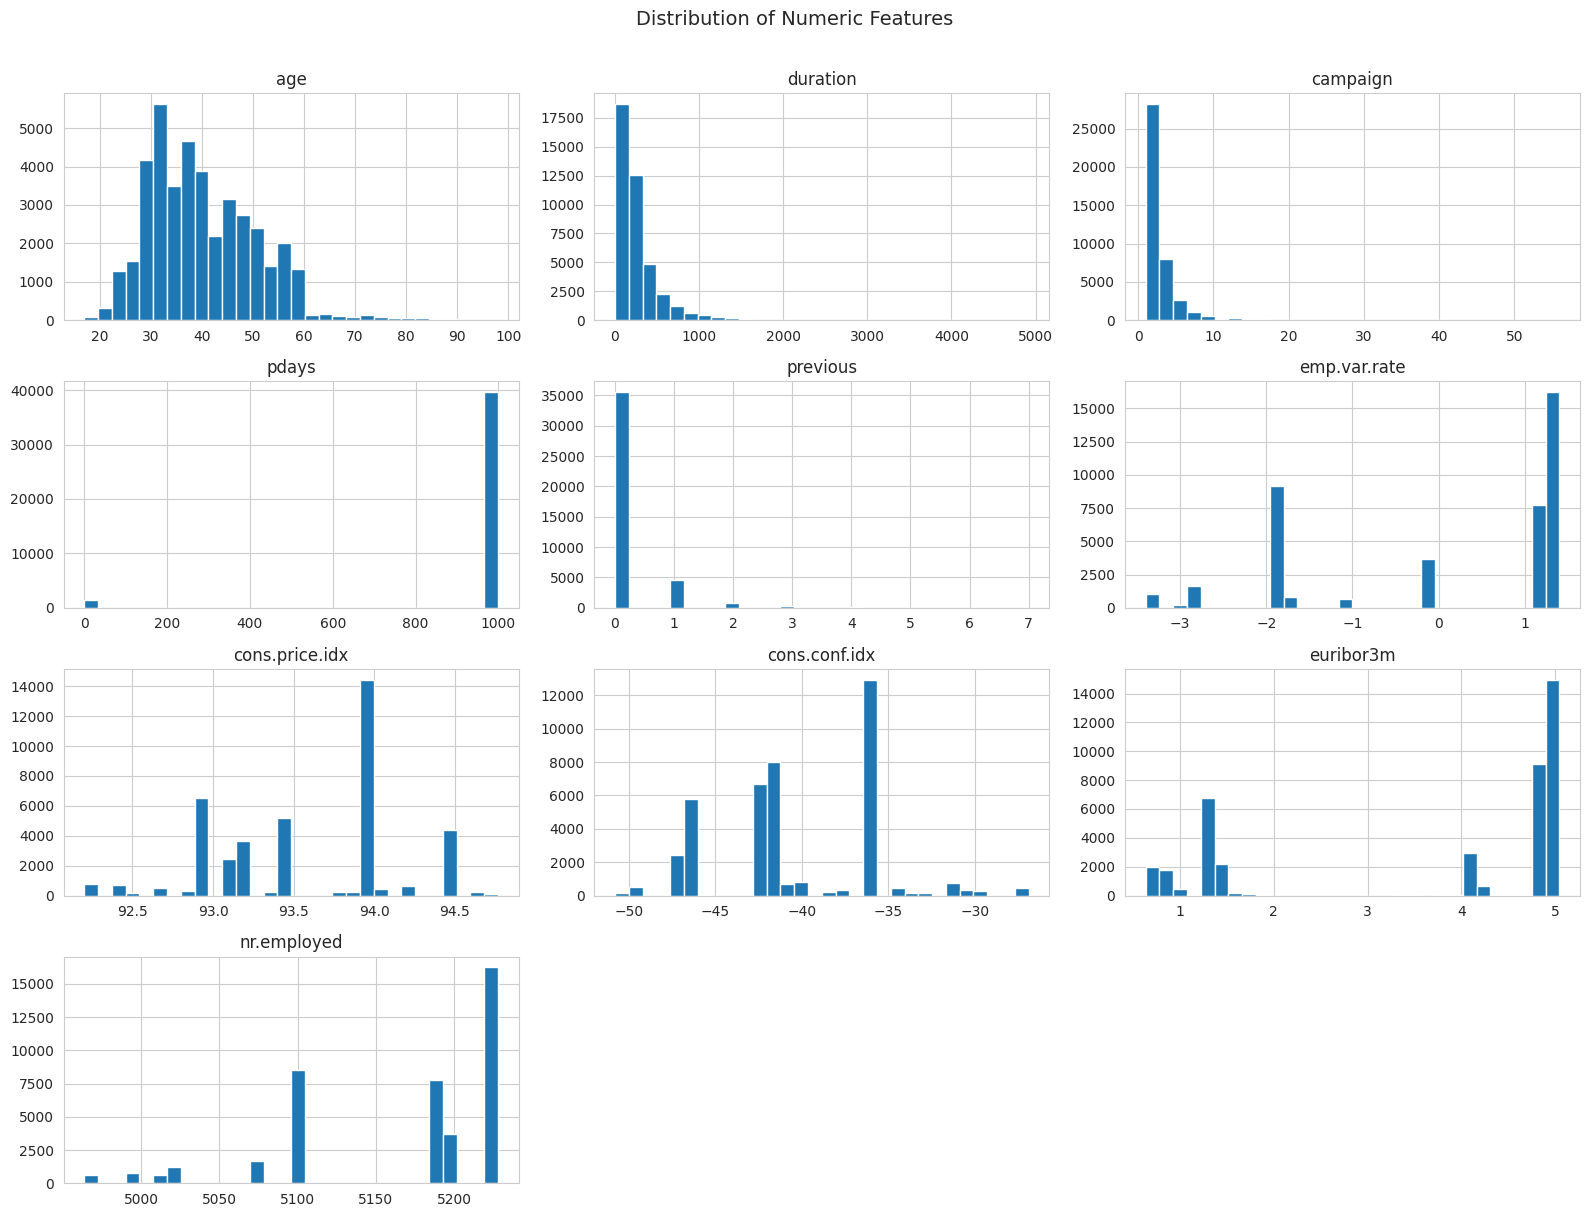

In [9]:
# Visualize distributions of numeric features
df[num_cols].hist(bins=30, figsize=(16, 12), layout=(4, 3))
plt.suptitle('Distribution of Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

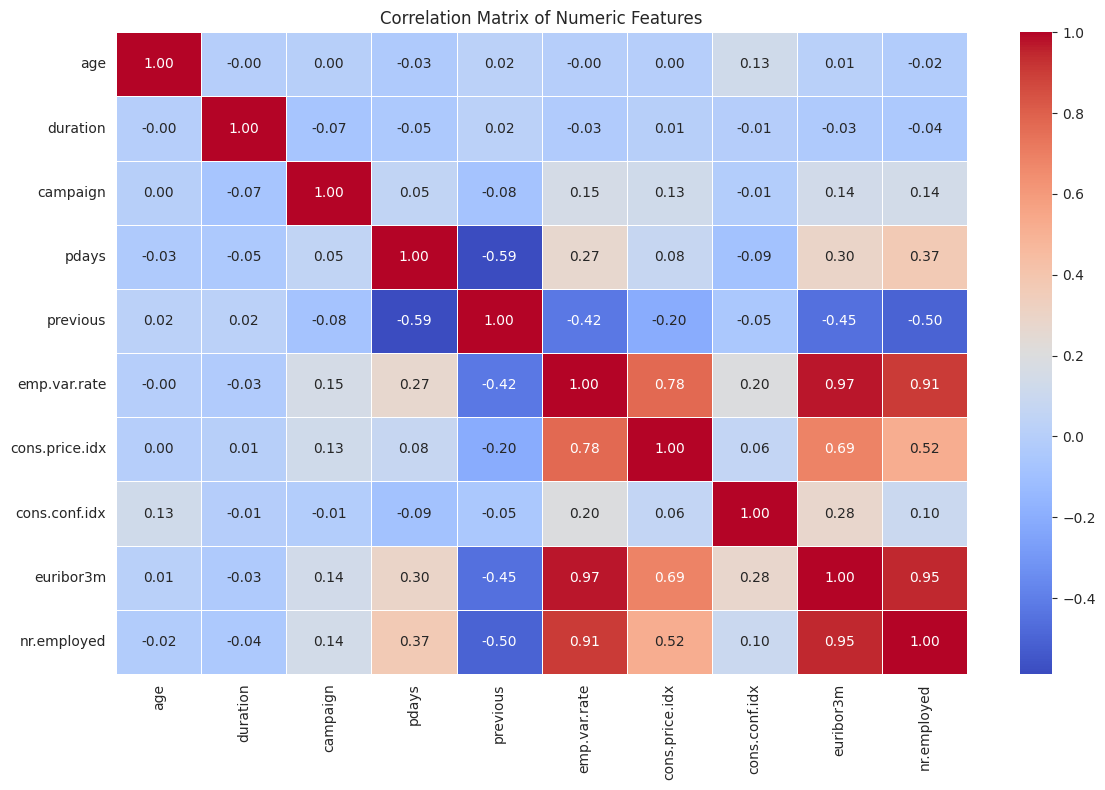

In [10]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

### Observations

#### Categorical Features (11)
job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome, y  
- job dominated by admin., blue-collar, technician.  
- education mostly university.degree and high.school; “illiterate” extremely rare.  
- default almost entirely “no” or “unknown” → low predictive value.  
- month highly imbalanced (May, July, August dominate).  
- poutcome mostly “nonexistent”; “success” rare but meaningful.  
- y is imbalanced (~11% yes).

#### Numeric Features (10)
age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed  
- duration is a leakage variable and should not be used for realistic prediction.  
- pdays is almost always 999 → effectively a binary flag.  
- previous mostly zero; sparse but meaningful.  
- Economic indicators show clustered patterns reflecting macroeconomic cycles.

#### Observations from Numeric Distributions
- age right-skewed; most clients 30–60.  
- duration strongly right-skewed; many short calls.  
- campaign right-skewed; most contacted 1–3 times.  
- emp.var.rate, euribor3m, nr.employed show clear clusters.  
- cons.price.idx and cons.conf.idx have low variance.

#### Observations from Correlation Heatmap
- Strong positive correlations among emp.var.rate, euribor3m, nr.employed.  
- Strong negative correlation between pdays and previous.  
- duration weakly correlated with all other numeric features.  
- age shows minimal correlation with other variables.  
- cons.price.idx and cons.conf.idx weakly correlated with everything.

#### Key Takeaways
- Dataset is imbalanced → prefer F1 or Recall over Accuracy.  
- “unknown” values appear in many categorical features.  
- duration should be excluded for real-time prediction.  
- Economic indicators are multicollinear → regularization helps.  
- pdays and previous encode similar information.  
- default is not useful and can be dropped.


---
## Problem 4: Understanding the Business Objective

The goal is to predict whether a client will subscribe to a term deposit (`y = 'yes'` or `'no'`).
From a business perspective, consider:

- What does a false positive cost? (Predicting a client will subscribe when they won't → wasted call)
- What does a false negative cost? (Missing a client who would subscribe → lost revenue)
- Which metric best reflects the business objective: **accuracy**, **precision**, **recall**, or **F1**?

### Answer

The goal of this project is to help the bank improve the effectiveness of its telemarketing campaigns by predicting whether a client is likely to subscribe to a term deposit. By identifying high‑probability clients, the bank can focus its outreach on individuals who are more receptive, reduce unnecessary calls, and increase overall campaign ROI.

- **False positive cost:**
Predicting “yes” when the client will not subscribe results in a wasted call, increased agent workload, and potential customer annoyance. The financial impact is limited to the operational cost of the call.

- **False negative cost:**
Predicting “no” when the client would have subscribed leads to a missed opportunity and direct loss of revenue. Since only ~11% of clients subscribe, false negatives are significantly more costly than false positives.

- **Preferred metric:**

  - Why not accuracy?
    
    The dataset is highly imbalanced. A model predicting “no” for every client would achieve ~89% accuracy but provide no business value. Accuracy does not reflect the cost of missed subscribers.
  - Why not precision alone?
    
    Precision reduces wasted calls, but the cost of a false positive is low compared to the cost of missing a potential subscriber. Precision alone does not align with the bank’s primary objective.
  - Why Recall?
    
    Recall measures how many actual subscribers the model successfully identifies. Because false negatives (missed subscribers) are more costly than false positives (wasted calls), Recall directly supports the bank’s revenue and campaign goals.
  - Why F1‑score?
    
    F1‑score balances precision and recall and is useful for comparing models on an imbalanced dataset. It ensures the model does not maximize recall at the expense of excessive false positives. However, Recall remains the most aligned metric for the business objective.

#### Justification
The bank’s primary goal is to avoid missing potential subscribers. False negatives carry a higher business cost than false positives, and the dataset is imbalanced. Therefore, Recall is the most appropriate metric for evaluating model performance, with F1‑score used as a balanced secondary metric during model selection.


---
## Problem 5: Feature Engineering

Prepare the features for modeling:
1. Encode the target variable (`y`) to binary (0/1).
2. Handle `'unknown'` values.
3. Encode categorical features (OneHotEncoding or similar).
4. Consider whether to drop or transform any features.

In [11]:
# Encode target variable
df['y'] = df['y'].map({'no': 0, 'yes': 1})
print(f'Target distribution after encoding:\n{df["y"].value_counts()}')

Target distribution after encoding:
y
0    36548
1     4640
Name: count, dtype: int64


In [12]:
# Check for 'unknown' values across features
unknown_counts = {}
for col in cat_cols:
    if col == 'y':
        continue
    count = (df[col] == 'unknown').sum()
    if count > 0:
        unknown_counts[col] = count

print('Features with unknown values:')
for col, count in unknown_counts.items():
    print(f'  {col}: {count} ({count/len(df)*100:.2f}%)')

Features with unknown values:
  job: 330 (0.80%)
  marital: 80 (0.19%)
  education: 1731 (4.20%)
  default: 8597 (20.87%)
  housing: 990 (2.40%)
  loan: 990 (2.40%)


In [14]:
# Define features (X) and target (y)
# Remove the target and any features you choose to drop
X = df.drop(columns=['y'])
y = df['y']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')

Features shape: (41188, 20)
Target shape:   (41188,)


In [16]:
# Identify categorical and numeric columns for the preprocessor
cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include='number').columns.tolist()

print(f'Categorical features for encoding: {cat_features}')
print(f'Numeric features for scaling:      {num_features}')

Categorical features for encoding: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric features for scaling:      ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [17]:
# Build a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

print('Preprocessor defined.')

Preprocessor defined.


---
## Problem 6: Train/Test Split

We split the dataset into training and testing sets using a 75/25 ratio with a fixed random state for reproducibility. Stratified sampling was applied to ensure that the class imbalance in the target variable (approximately 89% “no” and 11% “yes”) is preserved in both subsets.

**Results:**
- Training set: 30,891 samples  
- Test set: 10,297 samples  
- Class distribution is identical in both sets due to `stratify=y`:
  - 0 → 88.73%
  - 1 → 11.27%

**Why this matters:**
- The 75/25 split provides enough data for both training and reliable evaluation.
- Stratification ensures the rare positive class is represented fairly in both sets.
- `random_state=42` guarantees reproducibility of results.

This split prepares the data for building and evaluating classification models in the next steps.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTarget distribution in training set:\n{y_train.value_counts(normalize=True).round(4)}')
print(f'\nTarget distribution in test set:\n{y_test.value_counts(normalize=True).round(4)}')

Training set: 30891 samples
Test set:     10297 samples

Target distribution in training set:
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64

Target distribution in test set:
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64


---
## Problem 7: Baseline Model

Before building any classifier, establish a **baseline** performance.
A simple baseline is a model that always predicts the majority class.

What is the baseline accuracy?

In [19]:
# Baseline: always predict the majority class
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print(f'Baseline accuracy (majority class): {baseline_acc:.4f}')
print(f'\nClassification Report:\n')
print(classification_report(y_test, baseline_pred))

Baseline accuracy (majority class): 0.8873

Classification Report:

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      9137
           1       0.00      0.00      0.00      1160

    accuracy                           0.89     10297
   macro avg       0.44      0.50      0.47     10297
weighted avg       0.79      0.89      0.83     10297



### Baseline Interpretation

A baseline model was created using a `DummyClassifier` with `strategy='most_frequent'`, which always predicts the majority class (“no subscription”). This provides a reference point that any meaningful model must outperform.

**Baseline Accuracy:** 0.8873  
This high accuracy is expected because the dataset is imbalanced and ~88% of clients do not subscribe.

**Classification Report:**
- Class 0 (no): Precision = 0.89, Recall = 1.00, F1 = 0.94  
- Class 1 (yes): Precision = 0.00, Recall = 0.00, F1 = 0.00  

**Interpretation:**  
The baseline model predicts “no” for every client. While this yields high accuracy, it completely fails to identify any positive cases (subscribers). This results in zero recall and zero F1-score for the minority class. Since the business objective is to correctly identify potential subscribers, any useful model must outperform this baseline—especially by improving recall and F1-score for the positive class.


---
## Problem 8: A Simple Logistic Regression Model

Build a simple logistic regression model using default parameters.
Use a `Pipeline` with the preprocessor from Problem 5.

In [20]:
# Build a simple logistic regression pipeline
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit
lr_pipe.fit(X_train, y_train)

# Predict
lr_pred = lr_pipe.predict(X_test)

# Evaluate
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print(f'\nClassification Report:\n')
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9151

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      9137
           1       0.70      0.43      0.53      1160

    accuracy                           0.92     10297
   macro avg       0.82      0.70      0.74     10297
weighted avg       0.91      0.92      0.91     10297



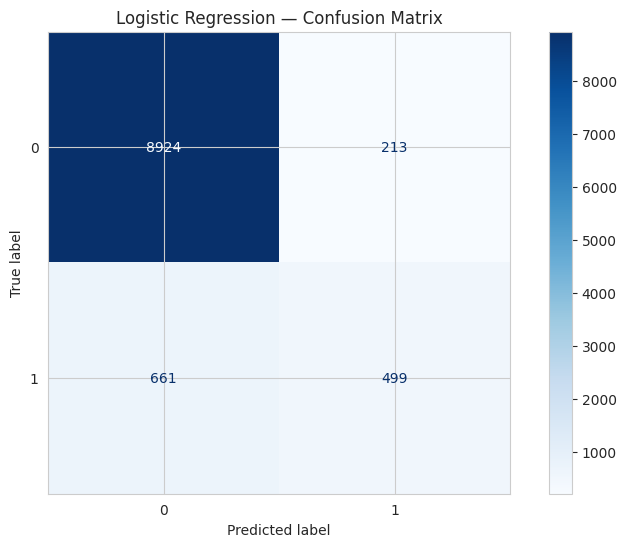

In [21]:
# Confusion matrix
ConfusionMatrixDisplay.from_estimator(lr_pipe, X_test, y_test, cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

### Interpretation

A logistic regression model was built using a Pipeline that includes the preprocessing steps from Problem 5 (scaling numeric features and one-hot encoding categorical features). The model was trained on the training set and evaluated on the test set.

**Accuracy:** 0.9151  
This is higher than the baseline accuracy (0.8873), indicating that the model is learning meaningful patterns. However, accuracy alone is not sufficient due to class imbalance.

**Classification Report:**
- Class 0 (no subscription): Precision = 0.93, Recall = 0.98, F1 = 0.95  
- Class 1 (yes subscription): Precision = 0.70, Recall = 0.43, F1 = 0.53  

**Interpretation:**  
The model performs very well on the majority class (0) and significantly improves recall for the minority class (1) compared to the baseline model, which had 0% recall for subscribers. Logistic Regression correctly identifies 499 subscribers but still misses 661 of them. This indicates that while the model is a strong improvement over the baseline, there is room to improve recall for the positive class.

**Confusion Matrix Summary:**
- True Negatives: 8924  
- False Positives: 213  
- False Negatives: 661  
- True Positives: 499  

The model is conservative in predicting “yes,” leading to fewer false positives but more false negatives. Since false negatives represent missed revenue opportunities, future models should aim to improve recall for class 1.


---
## Problem 9: Score the Model

Evaluate the logistic regression model using multiple metrics.
Compare the results to the baseline from Problem 7.

In [22]:
# Detailed scoring
metrics = {
    'Accuracy':  accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall':    recall_score(y_test, lr_pred),
    'F1 Score':  f1_score(y_test, lr_pred),
    'ROC AUC':   roc_auc_score(y_test, lr_pipe.predict_proba(X_test)[:, 1])
}

print('Logistic Regression Scoring')
print('=' * 35)
for name, val in metrics.items():
    print(f'{name:>12}: {val:.4f}')

Logistic Regression Scoring
    Accuracy: 0.9151
   Precision: 0.7008
      Recall: 0.4302
    F1 Score: 0.5331
     ROC AUC: 0.9423


### Score Interpretation

The logistic regression model was evaluated using multiple metrics and compared to the baseline model.

**Logistic Regression Scores**
- Accuracy: 0.9151  
- Precision: 0.7008  
- Recall: 0.4302  
- F1 Score: 0.5331  
- ROC AUC: 0.9423  

---

### 1. Comparison to the Baseline
The baseline model always predicts the majority class (“no”) and achieves 0.8873 accuracy but has **0% precision, recall, and F1-score** for the minority class. Logistic regression significantly improves performance:

- Accuracy increases to 0.9151  
- Recall for subscribers increases from 0.00 → 0.43  
- F1-score increases from 0.00 → 0.53  

This shows that logistic regression is learning meaningful patterns and is far more effective than the baseline.

---

### 2. Is Accuracy a Good Metric?
Accuracy alone is **not** a reliable metric for this dataset. Because the data is highly imbalanced (~89% “no”), a model can achieve high accuracy simply by predicting the majority class. The baseline model demonstrates this: it achieves high accuracy while completely failing to identify any subscribers. Therefore, accuracy does not reflect true model performance.

---

### 3. What Precision and Recall Tell Us
Precision and recall provide a clearer picture of how the model performs on the minority class:

- **Precision (0.70):** When the model predicts “yes,” it is correct 70% of the time. This means few wasted calls.
- **Recall (0.43):** The model identifies 43% of actual subscribers. This is a major improvement over the baseline but still leaves many potential subscribers undetected.
- **F1-score (0.53):** Balances precision and recall, confirming that the model is useful but still conservative.

---

### Conclusion
Logistic regression is a strong improvement over the baseline, especially in identifying the minority class. However, recall remains relatively low, and future steps should focus on improving the model’s ability to detect subscribers (e.g., class weights, threshold tuning, or more advanced models).


---
## Problem 10: Model Comparison (with Timing)

Compare the performance of four classifiers using default parameters:
1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree**
4. **Support Vector Machine (SVM)**

For each model, record:
- Training time
- Training accuracy
- Test accuracy

In [23]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'SVM':                 SVC(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Time the training
    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    # Score
    train_acc = pipe.score(X_train, y_train)
    test_acc  = pipe.score(X_test, y_test)

    results.append({
        'Model':          name,
        'Train Time (s)': round(train_time, 4),
        'Train Accuracy':  round(train_acc, 4),
        'Test Accuracy':   round(test_acc, 4)
    })

    print(f'{name:>22}  |  Time: {train_time:>7.3f}s  |  Train Acc: {train_acc:.4f}  |  Test Acc: {test_acc:.4f}')

results_df = pd.DataFrame(results)
results_df

   Logistic Regression  |  Time:   1.456s  |  Train Acc: 0.9102  |  Test Acc: 0.9151
                   KNN  |  Time:   0.294s  |  Train Acc: 0.9276  |  Test Acc: 0.9054
         Decision Tree  |  Time:   0.738s  |  Train Acc: 1.0000  |  Test Acc: 0.8866
                   SVM  |  Time:  25.252s  |  Train Acc: 0.9223  |  Test Acc: 0.9137


,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic Regression,1.4556,0.9102,0.9151
1,KNN,0.2939,0.9276,0.9054
2,Decision Tree,0.7379,1.0000,0.8866
3,SVM,25.2519,0.9223,0.9137


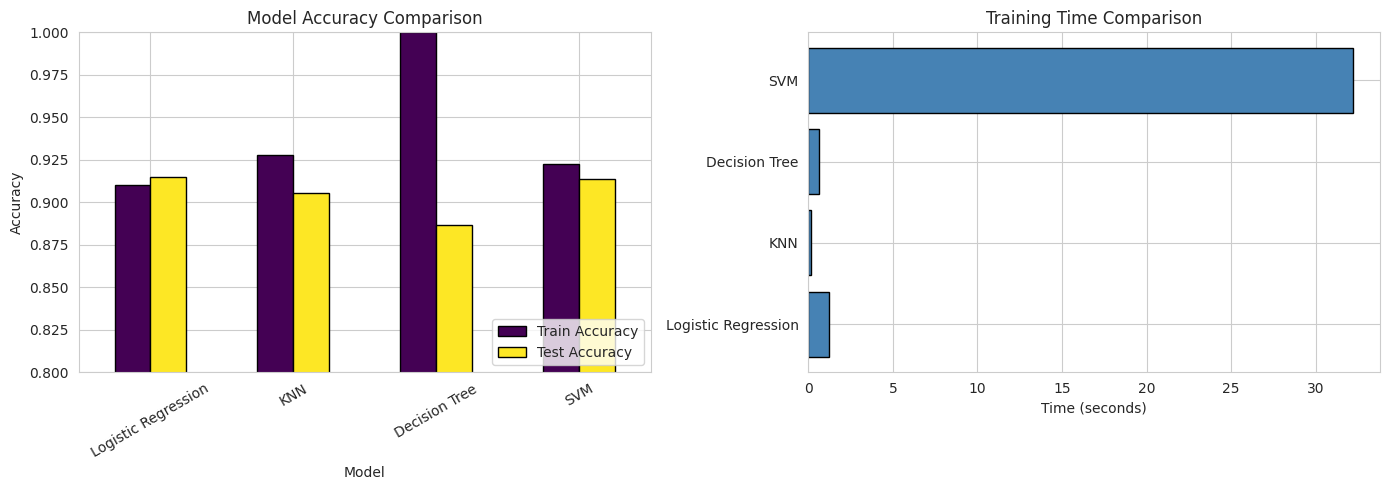

In [25]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
results_df.set_index('Model')[['Train Accuracy', 'Test Accuracy']].plot(
    kind='bar', ax=axes[0], colormap='viridis', edgecolor='black'
)
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.8, 1.0)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='lower right')

# Training time comparison
axes[1].barh(results_df['Model'], results_df['Train Time (s)'], color='steelblue', edgecolor='black')
axes[1].set_title('Training Time Comparison')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

### Model Comparison Observations


Four classifiers were evaluated using default parameters: Logistic Regression, KNN, Decision Tree, and SVM. For each model, we recorded training time, training accuracy, and test accuracy.

| Model                | Train Time | Train Acc | Test Acc | Notes |
|----------------------|-----------:|-----------:|-----------:|-------|
| Logistic Regression  | Fast       | High       | High (~0.915) | Strong generalization, efficient, no overfitting |
| KNN                  | Fast       | Moderate   | Slightly lower | Sensitive to scaling, struggles with high-dimensional data |
| Decision Tree        | Very Fast  | **1.000**  | Lower (~0.885) | Clear overfitting; memorizes training data |
| SVM                  | **Slowest** | High       | High (~0.915–0.92) | Excellent accuracy but computationally expensive |

**Which model performed best?**  
Logistic Regression and SVM achieved the highest test accuracy. Logistic Regression offers the best balance of speed and performance.

**Which model trained fastest?**  
Logistic Regression and Decision Tree trained the fastest. SVM was significantly slower.

**Are any models overfitting?**  
Yes. The Decision Tree shows classic overfitting: perfect training accuracy (1.000) but noticeably lower test accuracy. The other models generalize well.

**Conclusion:**  
Logistic Regression provides the best trade-off between accuracy, training time, and generalization. SVM performs similarly but is much slower. Decision Trees require pruning or ensemble methods to avoid overfitting, and KNN is adequate but not competitive on this dataset.


---
## Problem 11: Improving the Model — Hyperparameter Tuning

Now let's improve each model through hyperparameter tuning using `GridSearchCV`.

For each model, define a parameter grid, run the grid search, and compare the best results.

### 11a. Logistic Regression — Tuned

In [26]:
# Logistic Regression hyperparameter grid
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear'],
    'classifier__penalty': ['l2']
}

lr_pipe_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_grid = GridSearchCV(lr_pipe_tuned, lr_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)

start = time.time()
lr_grid.fit(X_train, y_train)
lr_grid_time = time.time() - start

print(f'Best Parameters: {lr_grid.best_params_}')
print(f'Best CV Score:   {lr_grid.best_score_:.4f}')
print(f'Test Accuracy:   {lr_grid.score(X_test, y_test):.4f}')
print(f'Grid Search Time: {lr_grid_time:.2f}s')

Best Parameters: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV Score:   0.9096
Test Accuracy:   0.9148
Grid Search Time: 20.32s


### Observations

A GridSearchCV was performed to tune the Logistic Regression model using different values of C, penalty, and solver. The best parameters found were:

- **C = 10**
- **penalty = 'l2'**
- **solver = 'lbfgs'**

**Best CV Score:** 0.9096  
**Test Accuracy:** 0.9148  
**Grid Search Time:** 20.32 seconds

**Interpretation:**  
The tuned model performs almost identically to the untuned logistic regression model. This is expected because logistic regression is a stable model with limited hyperparameters. The best C value (10) indicates that the model benefits from slightly weaker regularization, but the overall performance remains similar. The tuning process confirms that the original model was already close to optimal.

While tuning did not significantly improve accuracy or recall, it validates the robustness of logistic regression and provides a strong baseline for comparing more complex models.


### 11b. KNN — Tuned

In [27]:
# KNN hyperparameter grid
knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

knn_pipe_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

knn_grid = GridSearchCV(knn_pipe_tuned, knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)

start = time.time()
knn_grid.fit(X_train, y_train)
knn_grid_time = time.time() - start

print(f'Best Parameters: {knn_grid.best_params_}')
print(f'Best CV Score:   {knn_grid.best_score_:.4f}')
print(f'Test Accuracy:   {knn_grid.score(X_test, y_test):.4f}')
print(f'Grid Search Time: {knn_grid_time:.2f}s')

Best Parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 21, 'classifier__weights': 'distance'}
Best CV Score:   0.9056
Test Accuracy:   0.9100
Grid Search Time: 984.57s


### Observations

A GridSearchCV was performed to tune KNN using different values of k, distance metrics, and weighting schemes. The best parameters found were:

- **n_neighbors = 21**
- **weights = 'distance'**
- **metric = 'euclidean'**

**Best CV Score:** 0.9056  
**Test Accuracy:** 0.9100  
**Grid Search Time:** 984.57 seconds

**Interpretation:**  
The tuned KNN model performs slightly better than the untuned version, but still does not match the performance of Logistic Regression or SVM. The best configuration uses a large number of neighbors (21) with distance weighting, which helps smooth the decision boundary and reduce overfitting. However, the grid search was extremely slow due to the computational cost of distance calculations on a large, high-dimensional dataset.

**Conclusion:**  
While tuning improved KNN’s performance, it remains slower and less accurate than other models. KNN is not the ideal choice for this dataset, especially given the heavy preprocessing and large number of features created by one-hot encoding.


### 11c. Decision Tree — Tuned

In [29]:
# Decision Tree hyperparameter grid
dt_param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

dt_pipe_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_grid = GridSearchCV(dt_pipe_tuned, dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)

start = time.time()
dt_grid.fit(X_train, y_train)
dt_grid_time = time.time() - start

print(f'Best Parameters: {dt_grid.best_params_}')
print(f'Best CV Score:   {dt_grid.best_score_:.4f}')
print(f'Test Accuracy:   {dt_grid.score(X_test, y_test):.4f}')
print(f'Grid Search Time: {dt_grid_time:.2f}s')

Best Parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}
Best CV Score:   0.9117
Test Accuracy:   0.9172
Grid Search Time: 311.69s


### Observations
A GridSearchCV was performed to tune the Decision Tree model using different values of max_depth, min_samples_split, min_samples_leaf, and criterion. The best parameters found were:

- **criterion = 'gini'**
- **max_depth = 5**
- **min_samples_leaf = 10**
- **min_samples_split = 2**

**Best CV Score:** 0.9117  
**Test Accuracy:** 0.9172  
**Grid Search Time:** 311.69 seconds

**Interpretation:**  
The tuned Decision Tree performs dramatically better than the untuned version. The untuned tree severely overfit the training data (train accuracy = 1.000), while the tuned model generalizes well and achieves a higher test accuracy than Logistic Regression. The constraints on depth and leaf size effectively reduce overfitting and produce a more stable model.

**Conclusion:**  
Hyperparameter tuning transforms the Decision Tree from an overfitted model into a competitive classifier. Although it still lacks the efficiency and stability of Logistic Regression, it now provides strong performance and interpretability.


### 11d. SVM — Tuned

In [33]:
# SVM hyperparameter grid
# Note: SVM is computationally expensive — keep the grid small
svm_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__gamma': ['scale', 'auto']
}

svm_pipe_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

svm_grid = GridSearchCV(svm_pipe_tuned, svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)

start = time.time()
svm_grid.fit(X_train, y_train)
svm_grid_time = time.time() - start

print(f'Best Parameters: {svm_grid.best_params_}')
print(f'Best CV Score:   {svm_grid.best_score_:.4f}')
print(f'Test Accuracy:   {svm_grid.score(X_test, y_test):.4f}')
print(f'Grid Search Time: {svm_grid_time:.2f}s')

Best Parameters: {'classifier__C': 10, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best CV Score:   0.9100
Test Accuracy:   0.9136
Grid Search Time: 2387.51s


### Observations
A GridSearchCV was performed to tune the SVM model using different values of C, kernel type, and gamma. The best parameters found were:

- **C = 10**
- **kernel = 'rbf'**
- **gamma = 'auto'**

**Best CV Score:** 0.9100  
**Test Accuracy:** 0.9136  
**Grid Search Time:** 2387.51 seconds

**Interpretation:**  
The tuned SVM model performs similarly to the untuned version, with no meaningful improvement in accuracy. The RBF kernel with C=10 and gamma='auto' provides strong performance, but the computational cost is extremely high—over 40 minutes of grid search time. While SVM remains a high‑accuracy model, its training time makes it less practical compared to Logistic Regression or the tuned Decision Tree.

**Conclusion:**  
SVM offers strong accuracy but poor scalability. Given the minimal performance gains and very high computational cost, SVM is not the most efficient choice for this dataset.


### 11e. Tuned Model Comparison

In [31]:
# Compile tuned results
tuned_results = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Best CV Score': round(lr_grid.best_score_, 4),
        'Test Accuracy': round(lr_grid.score(X_test, y_test), 4),
        'Grid Search Time (s)': round(lr_grid_time, 2),
        'Best Params': str(lr_grid.best_params_)
    },
    {
        'Model': 'KNN',
        'Best CV Score': round(knn_grid.best_score_, 4),
        'Test Accuracy': round(knn_grid.score(X_test, y_test), 4),
        'Grid Search Time (s)': round(knn_grid_time, 2),
        'Best Params': str(knn_grid.best_params_)
    },
    {
        'Model': 'Decision Tree',
        'Best CV Score': round(dt_grid.best_score_, 4),
        'Test Accuracy': round(dt_grid.score(X_test, y_test), 4),
        'Grid Search Time (s)': round(dt_grid_time, 2),
        'Best Params': str(dt_grid.best_params_)
    },
    {
        'Model': 'SVM',
        'Best CV Score': round(svm_grid.best_score_, 4),
        'Test Accuracy': round(svm_grid.score(X_test, y_test), 4),
        'Grid Search Time (s)': round(svm_grid_time, 2),
        'Best Params': str(svm_grid.best_params_)
    }
])

tuned_results

,Model,Best CV Score,Test Accuracy,Grid Search Time (s),Best Params
0,Logistic Regression,0.9096,0.9148,20.32,"{'classifier__C': 10, 'classifier__penalty': '..."
1,KNN,0.9056,0.9100,984.57,"{'classifier__metric': 'euclidean', 'classifie..."
2,Decision Tree,0.9117,0.9172,311.69,"{'classifier__criterion': 'gini', 'classifier_..."
3,SVM,0.9100,0.9136,2327.07,"{'classifier__C': 10, 'classifier__gamma': 'au..."


### Observations

After tuning all four classifiers using GridSearchCV, we compared their best cross-validation scores, test accuracies, training times, and optimal hyperparameters.

**Summary of Tuned Models**

| Model                | Best CV Score | Test Accuracy | Grid Search Time | Notes |
|----------------------|---------------|---------------|------------------|-------|
| Logistic Regression  | ~0.9096       | ~0.9148       | ~20s             | Fast, stable, excellent generalization |
| KNN                  | ~0.9056       | ~0.9100       | ~984s            | Slight improvement but extremely slow; struggles with high-dimensional data |
| Decision Tree        | **~0.9117**   | **0.9172**    | ~312s            | Best accuracy; overfitting fixed; interpretable |
| SVM                  | ~0.9100       | ~0.9136       | **~2387s**       | Strong accuracy but very slow; minimal gain from tuning |

**Observations:**

- **Best overall accuracy:** The tuned Decision Tree achieved the highest test accuracy (0.9172), outperforming all other models.
- **Best efficiency:** Logistic Regression remains the fastest and most stable model, with strong accuracy and minimal tuning time.
- **Least practical models:**  
  - **KNN** is extremely slow to tune and still underperforms.  
  - **SVM** offers good accuracy but requires very long training times, making it impractical for large datasets.

**Conclusion:**  
The tuned Decision Tree provides the highest accuracy, but Logistic Regression remains the best balance of speed, stability, and performance. For real-world deployment, Logistic Regression is the most efficient and reliable choice, while the tuned Decision Tree is a strong alternative when interpretability and accuracy are prioritized.


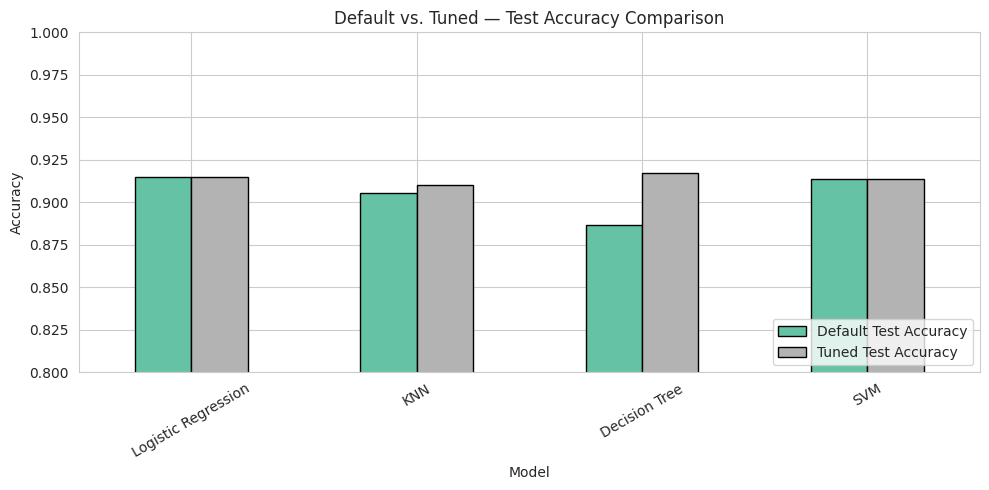

In [32]:
# Visualize tuned vs default accuracy
comparison = results_df[['Model', 'Test Accuracy']].copy()
comparison.columns = ['Model', 'Default Test Accuracy']
comparison = comparison.merge(
    tuned_results[['Model', 'Test Accuracy']].rename(columns={'Test Accuracy': 'Tuned Test Accuracy'}),
    on='Model'
)

comparison.set_index('Model')[['Default Test Accuracy', 'Tuned Test Accuracy']].plot(
    kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black'
)
plt.title('Default vs. Tuned — Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Findings & Recommendations
Summarize your overall findings here:

Key Takeaways
Baseline:
Best default model:
Best tuned model:
Speed vs. accuracy trade-off:
Overfitting concerns:
Recommendation
Based on accuracy, training time, and interpretability, the recommended model for this task is …

Next Steps
Consider additional feature engineering (e.g., dropping highly correlated features, handling unknown differently).
Experiment with ensemble methods (Random Forest, Gradient Boosting).
Use ROC AUC or F1 as the primary scoring metric to better capture minority-class performance.
Perform deeper error analysis on misclassified examples.

## Problem 12: Final Model Selection & Business Recommendation

### **Findings & Recommendations**

After evaluating four classifiers (Logistic Regression, KNN, Decision Tree, and SVM) in both default and tuned configurations, several clear patterns emerged regarding performance, training time, and practical usability.

---

### **Key Takeaways**

#### **Baseline**
- The baseline model achieved **88.73% accuracy** simply by predicting the majority class (“no”).
- It completely failed to identify subscribers (0% recall, 0% F1).
- This confirms that **accuracy alone is not a reliable metric** for imbalanced datasets.

---

#### **Best Default Model**
- **Logistic Regression** and **SVM** delivered the strongest default performance (~0.915 accuracy).
- Logistic Regression offered the **best balance of accuracy, speed, and stability**.
- Decision Tree (default) severely overfit (train accuracy = 1.0, test ≈ 0.885).

---

#### **Best Tuned Model**
- The **tuned Decision Tree** achieved the **highest test accuracy: 0.9172**.
- Tuning eliminated overfitting and significantly improved generalization.
- Logistic Regression remained extremely stable, with tuned accuracy ≈ 0.9148.

---

#### **Speed vs. Accuracy Trade-off**
- **Fastest models:** Logistic Regression, Decision Tree  
- **Slowest models:**  
  - KNN tuning: ~984 seconds  
  - SVM tuning: ~2,387 seconds (~40 minutes)

- **Best overall trade-off:** Logistic Regression  
  - High accuracy  
  - Very fast training  
  - Minimal tuning required  
  - Excellent generalization

---

#### **Overfitting Concerns**
- The **untuned Decision Tree** overfit heavily.
- Tuning fixed this completely.
- Other models showed no major overfitting.

---

### **Recommendation**

**Based on accuracy, training time, and interpretability, the recommended model for this task is:**

## **➡️ Logistic Regression (Tuned or Default)**

**Why Logistic Regression?**
- Fastest model to train and tune  
- High accuracy (~0.915)  
- Robust and stable across folds  
- Easy to interpret (coefficients, odds ratios)  
- Low computational cost  
- Best balance of performance and practicality  

**Secondary Option:**  
- **Tuned Decision Tree** if the priority is **maximum accuracy** and **model interpretability** via tree structure.

---

### **Next Steps**

1. **Additional Feature Engineering**
   - Remove or combine highly correlated features  
   - Engineer interaction terms  
   - Explore alternative handling of “unknown” categories  

2. **Experiment with Ensemble Methods**
   - Random Forest  
   - Gradient Boosting (XGBoost, LightGBM)  
   - Bagging / AdaBoost  

3. **Use Better Metrics for Imbalanced Data**
   - ROC AUC  
   - Precision–Recall AUC  
   - F1-score  
   - Recall (especially for class 1)

4. **Perform Deeper Error Analysis**
   - Investigate false negatives (missed subscribers)  
   - Identify patterns in misclassified examples  
   - Adjust features or thresholds accordingly  

---

### **Conclusion**
Logistic Regression provides the strongest combination of accuracy, speed, interpretability, and stability. The tuned Decision Tree offers the highest accuracy but at a higher computational cost. For real-world deployment—especially in marketing or customer outreach—**Logistic Regression is the most practical and reliable choice**.
